In [6]:
import pandas as pd
import os

# Define the file path using a raw string to handle Windows backslashes safely
file_path = r"C:\Users\matias\Documents\Vision-Aided-Beamformer\tests\dataset_out\Avance_1\benchmark_A.parquet"

# Verify if the file exists before attempting to load it
if os.path.exists(file_path):
    # Load the Parquet file into a Pandas DataFrame
    df_metrics = pd.read_parquet(file_path)
    
    # Filter out all rows where rt60 is 0.0 (anechoic conditions) and reset the index
    df_metrics = df_metrics[df_metrics['rt60'] > 0.0].reset_index(drop=True)
    
    print(f"Dataset successfully loaded and filtered (RT60 > 0.0)! Shape: {df_metrics.shape}\n")
    
    # Display the first few rows to confirm data integrity
    display(df_metrics.head())
    
    # Optional: Print all column names to quickly review the available metrics
    # print("Available columns:", df_metrics.columns.tolist())
else:
    print(f"Error: File not found at the specified path:\n{file_path}")
    print("Please check your current working directory using 'import os; print(os.getcwd())'.")

Dataset successfully loaded and filtered (RT60 > 0.0)! Shape: (480, 53)



,processor,rt60,M,N_interferences,mismatch_pos,isir_db,mismatch_gain,mismatch_phase,use_wpe,t_early_s,...,Delta_bf_SIR,Delta_bf_SAR,Delta_bf_SINR,Delta_tot_PESQ,Delta_tot_STOI,Delta_tot_CD,Delta_tot_SDR,Delta_tot_SIR,Delta_tot_SAR,Delta_tot_SINR
0,DS,0.3,4,1,0.0,0,0,0,False,0.024,...,1.001037,0.698812,1.352581,0.063068,0.052456,-1.059660,1.030900,1.001037,0.698812,1.352581
1,MVDR_(VAD)),0.3,4,1,0.0,0,0,0,False,0.024,...,1.922964,-0.544392,2.037188,0.120515,0.083597,-1.547192,1.444275,1.922964,-0.544392,2.037188
2,RTF-MVDR (VAD),0.3,4,1,0.0,0,0,0,False,0.024,...,11.046063,0.609317,11.313811,0.103855,0.080571,-0.147712,7.384764,11.046063,0.609317,11.313811
3,MVDR_SPP,0.3,4,1,0.0,0,0,0,False,0.024,...,0.855107,-1.552865,1.001850,0.070976,0.061523,-1.489623,0.262848,0.855107,-1.552865,1.001850
4,MPDR,0.3,4,1,0.0,0,0,0,False,0.024,...,2.062744,-1.301733,2.199565,0.077645,0.065626,-1.273243,1.291675,2.062744,-1.301733,2.199565


In [7]:
# ==============================================================================
# BLOCK 1: GLOBAL STYLING MACROS AND EXPORT PATHS
# ==============================================================================
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define the root directory to save all generated figures for the thesis
FIGURES_DIR = r"C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Configure the global plotting style to match academic LaTeX standards
def set_thesis_plot_style():
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Uses a serif font and sizes appropriate for an A4 LaTeX document.
    """
    sns.set_theme(style="whitegrid", context="paper")
    
    plt.rcParams.update({
        "font.family": "serif",          # Matches standard LaTeX font
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,                 # Base font size
        "axes.titlesize": 12,            # Subplot title size
        "axes.labelsize": 11,            # X and Y label size
        "xtick.labelsize": 9,            # Tick labels
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,
        "figure.titlesize": 13,
        "figure.dpi": 300,               # High resolution for print
        "savefig.dpi": 300,
        "savefig.bbox": "tight",         # Removes unnecessary white space
        "lines.linewidth": 1,
        "lines.markersize": 5
    })

# Apply the style settings
set_thesis_plot_style()

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\mics_no_wpe.pdf


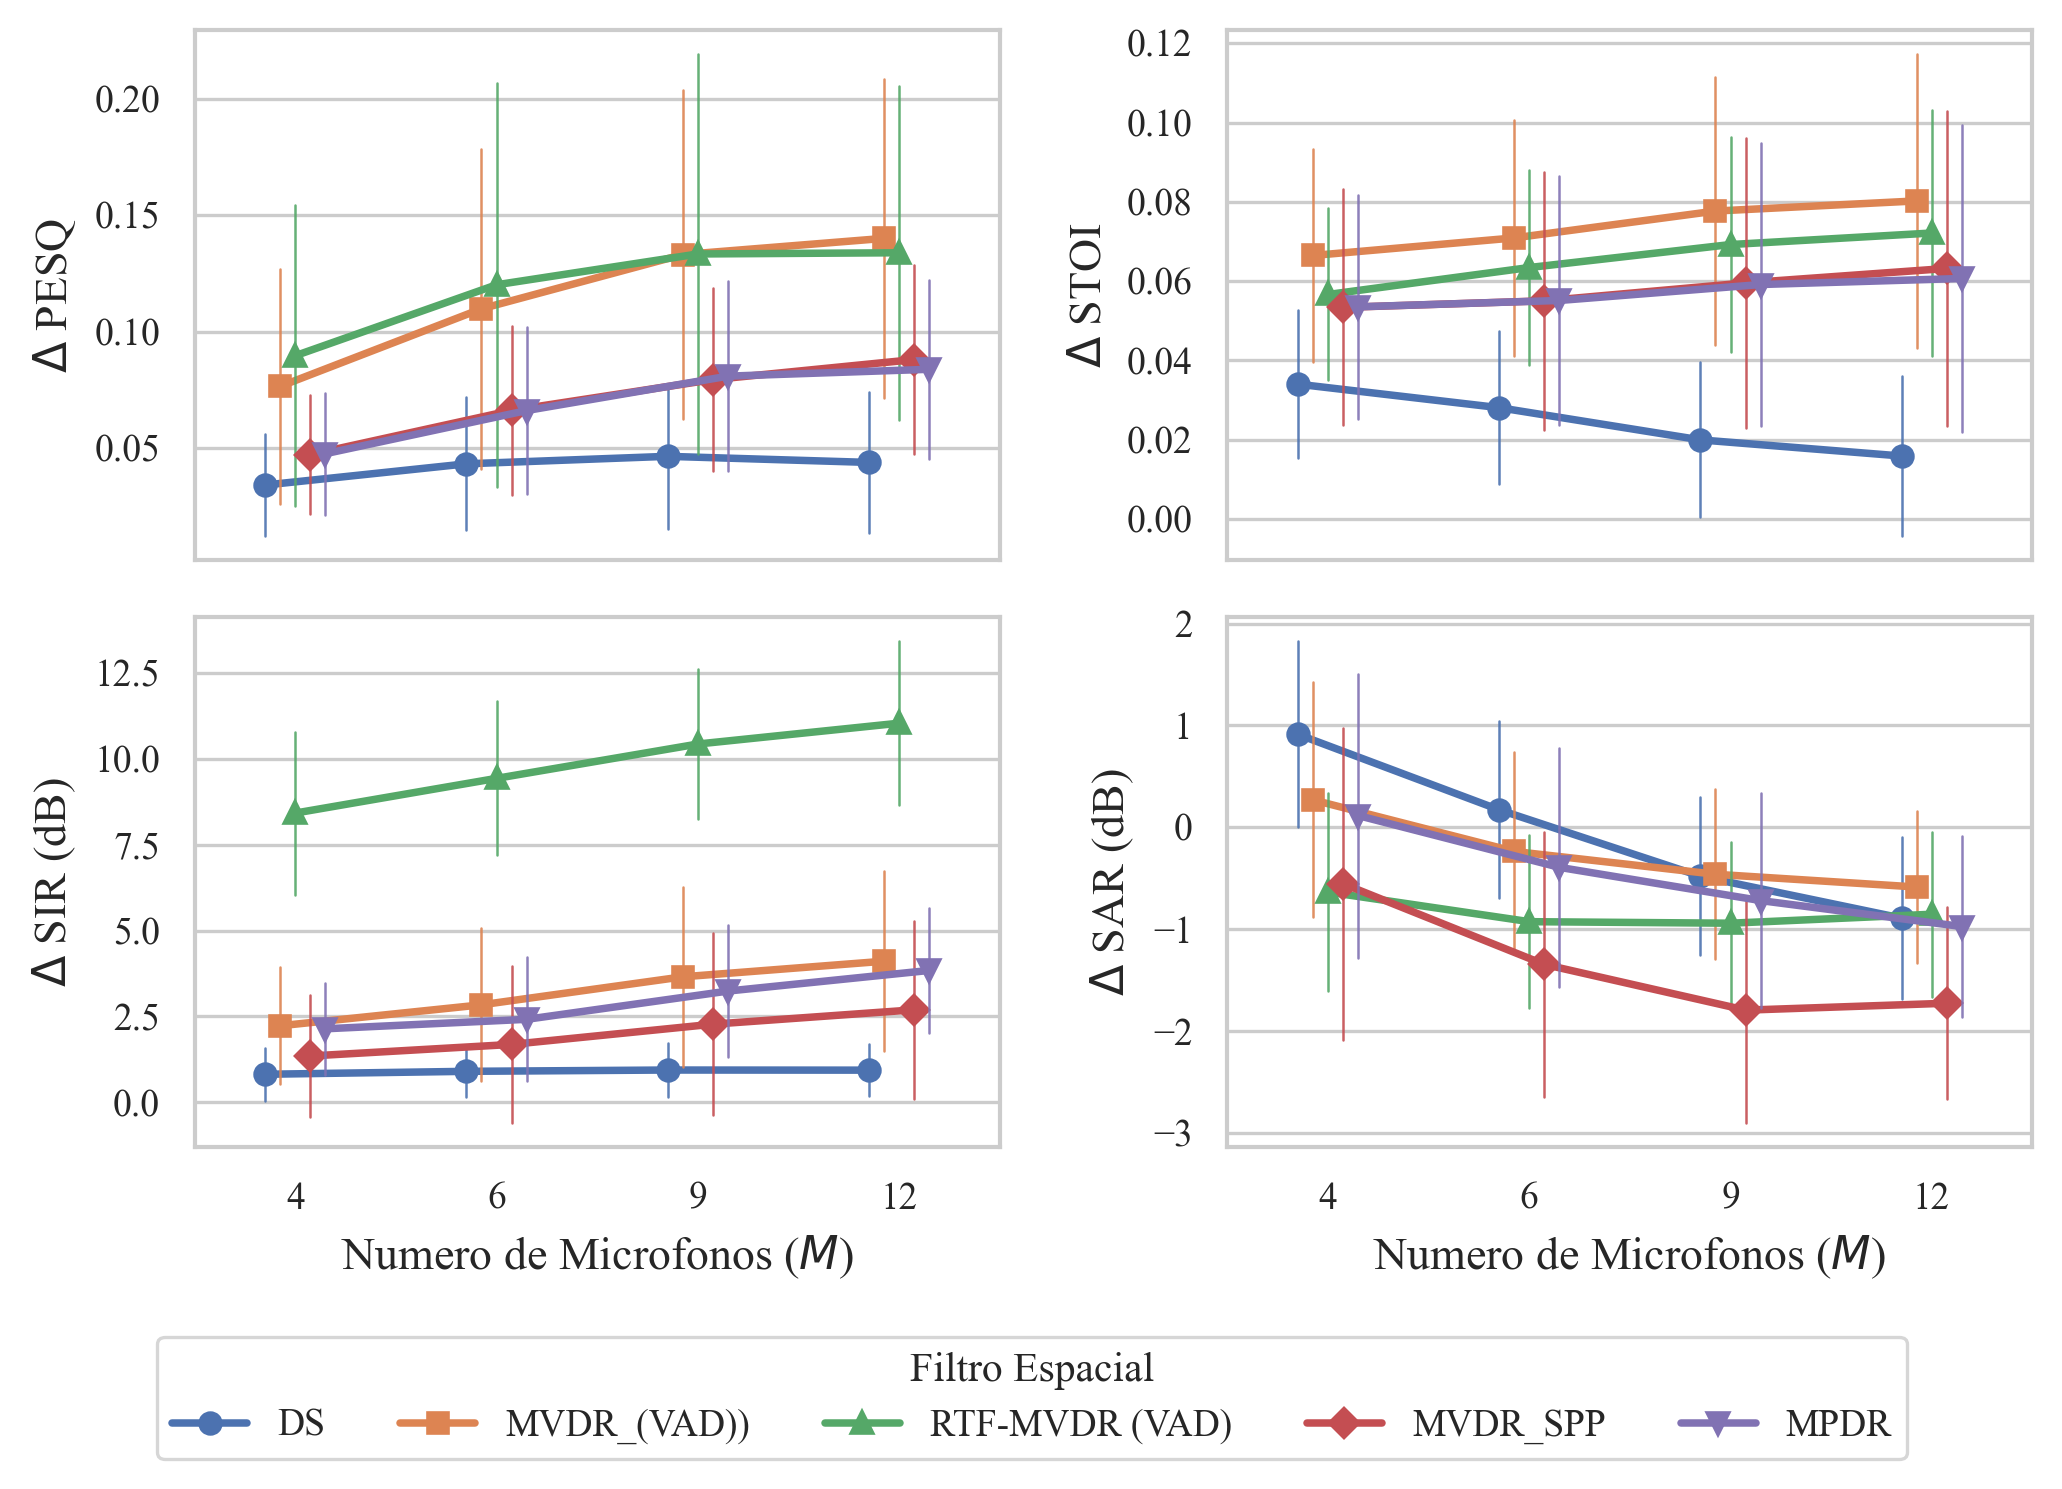

In [8]:
# ==============================================================================
# BLOCK 2: GENERATE BEAMFORMER PERFORMANCE PLOT (WITHOUT WPE) - COMPACT Y-LABELS
# ==============================================================================

def plot_beamformer_deltas_vs_m_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis 
    to maximize plotting area.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == True].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    # Height adjusted back to 5.0 since we removed the titles
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='M', 
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Numero de Microfonos ($M$)')
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Filtro Espacial',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "mics_no_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_m_compact(df_metrics)

In [3]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == False].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='N_interferences',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        # -------------------------------------------------------------
        # INVERT Y-AXIS SPECIFICALLY FOR SAR
        # -------------------------------------------------------------

        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Numero de Interferencias I') # Updated label
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        if 'SAR' in metric_col:
            ax.invert_yaxis()     
        

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Spatial Filter',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "deltas_vs_interferences.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

NameError: name 'df_metrics' is not defined

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\t60_sin_wpe.pdf


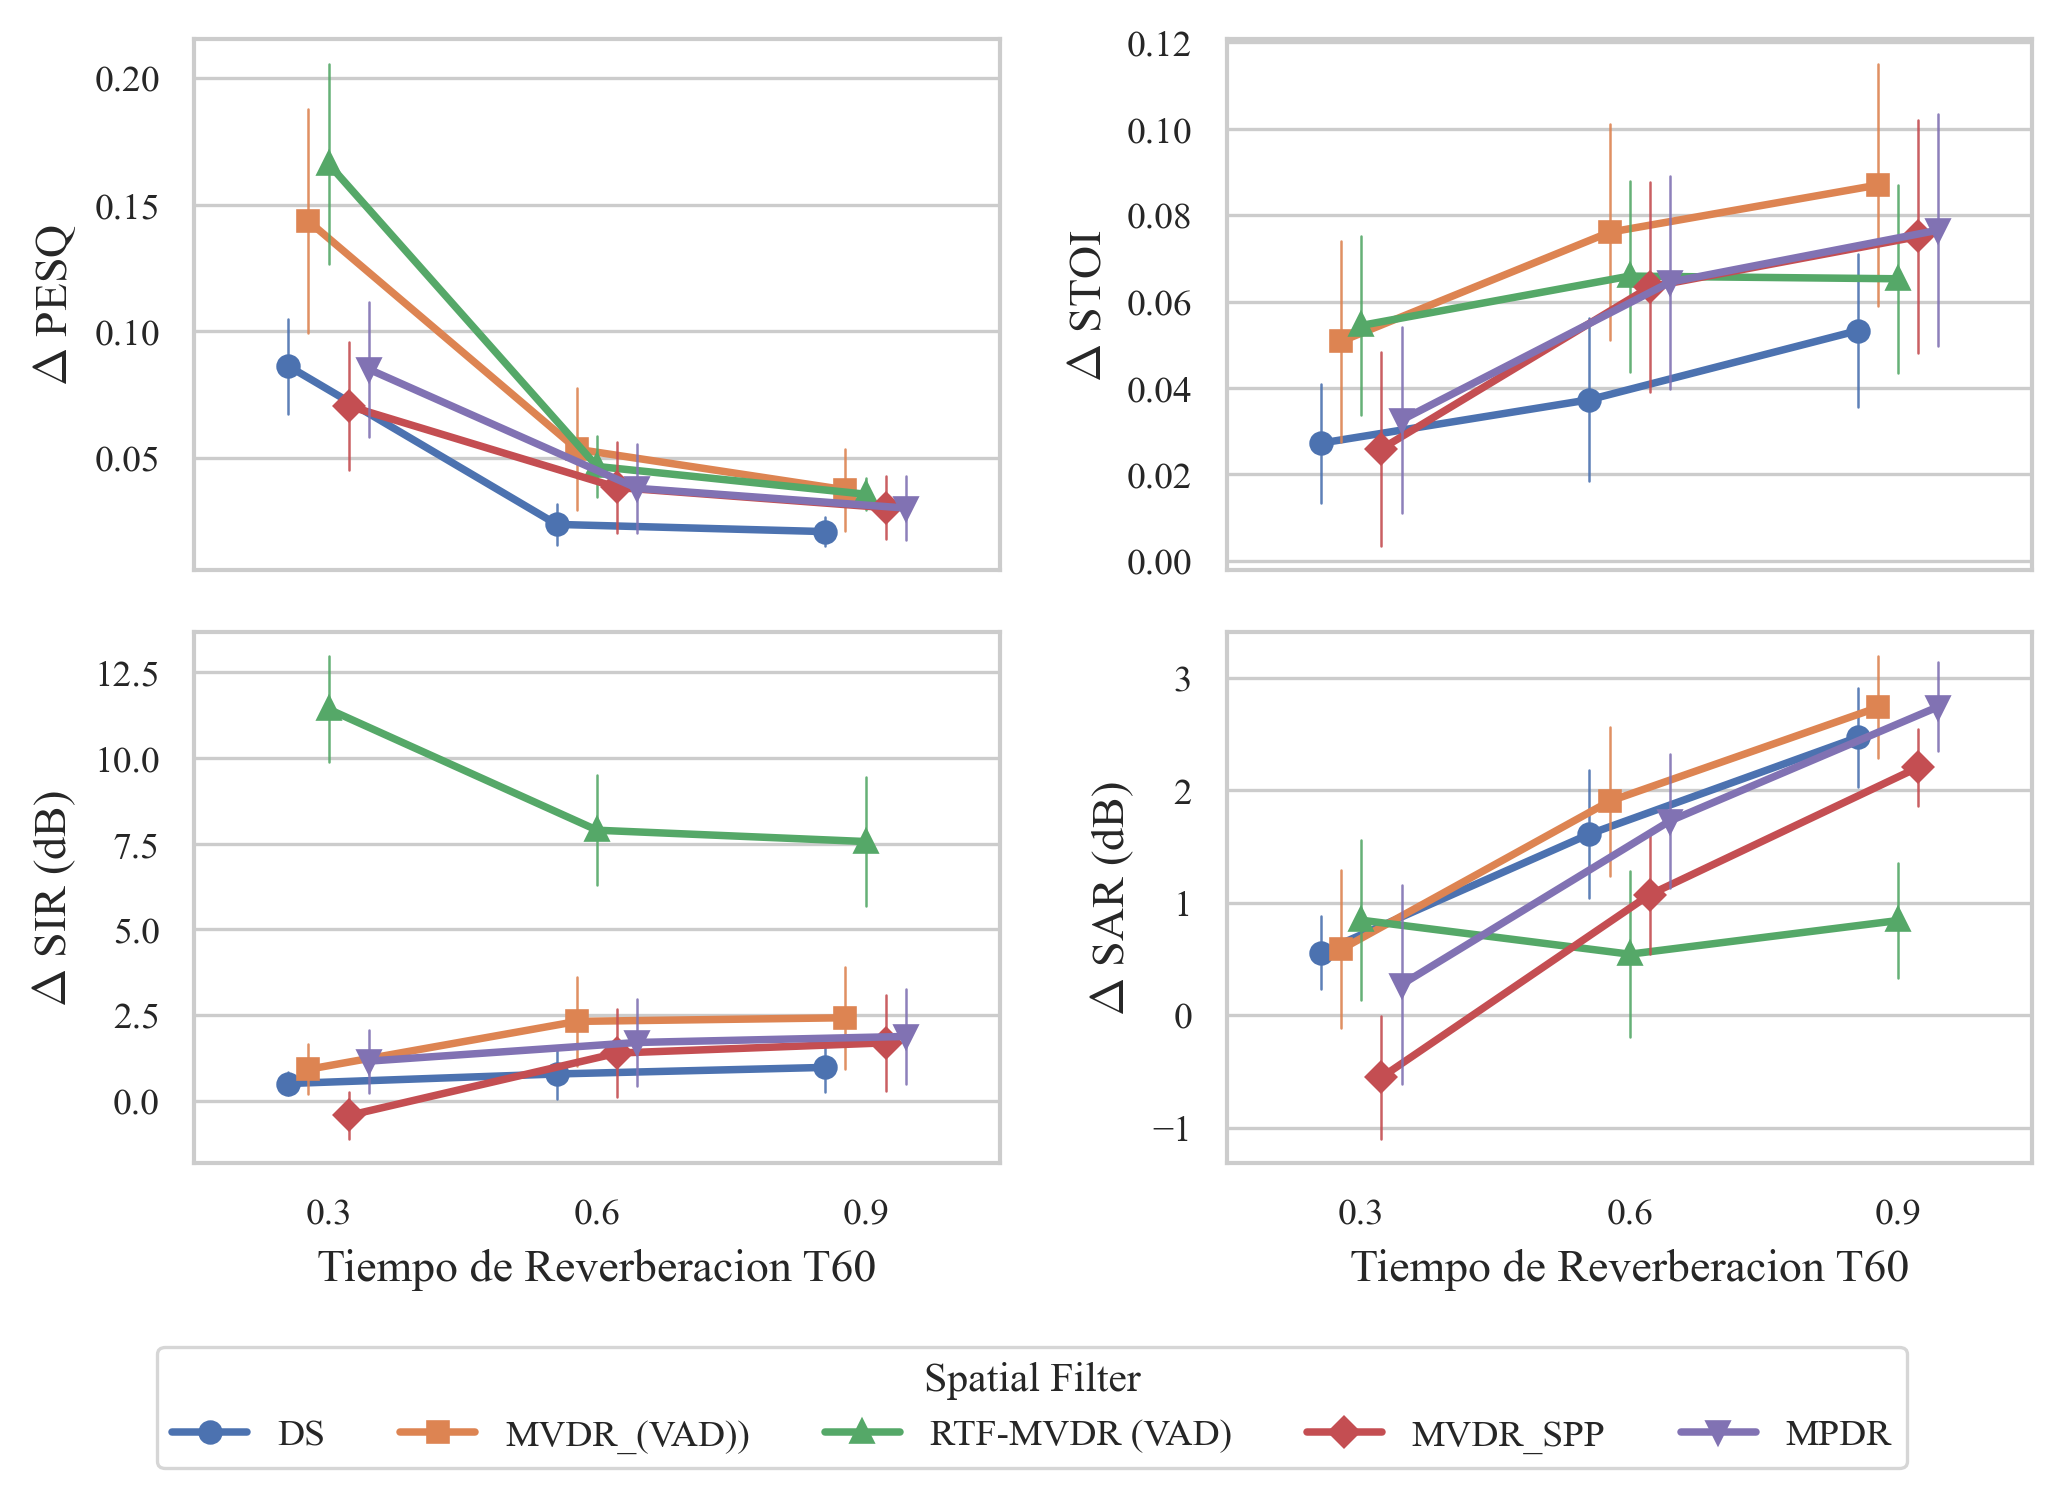

In [123]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == False].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2,figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='rt60',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberacion T60') # Updated label
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Spatial Filter',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "t60_sin_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\t60_con_wpe.pdf


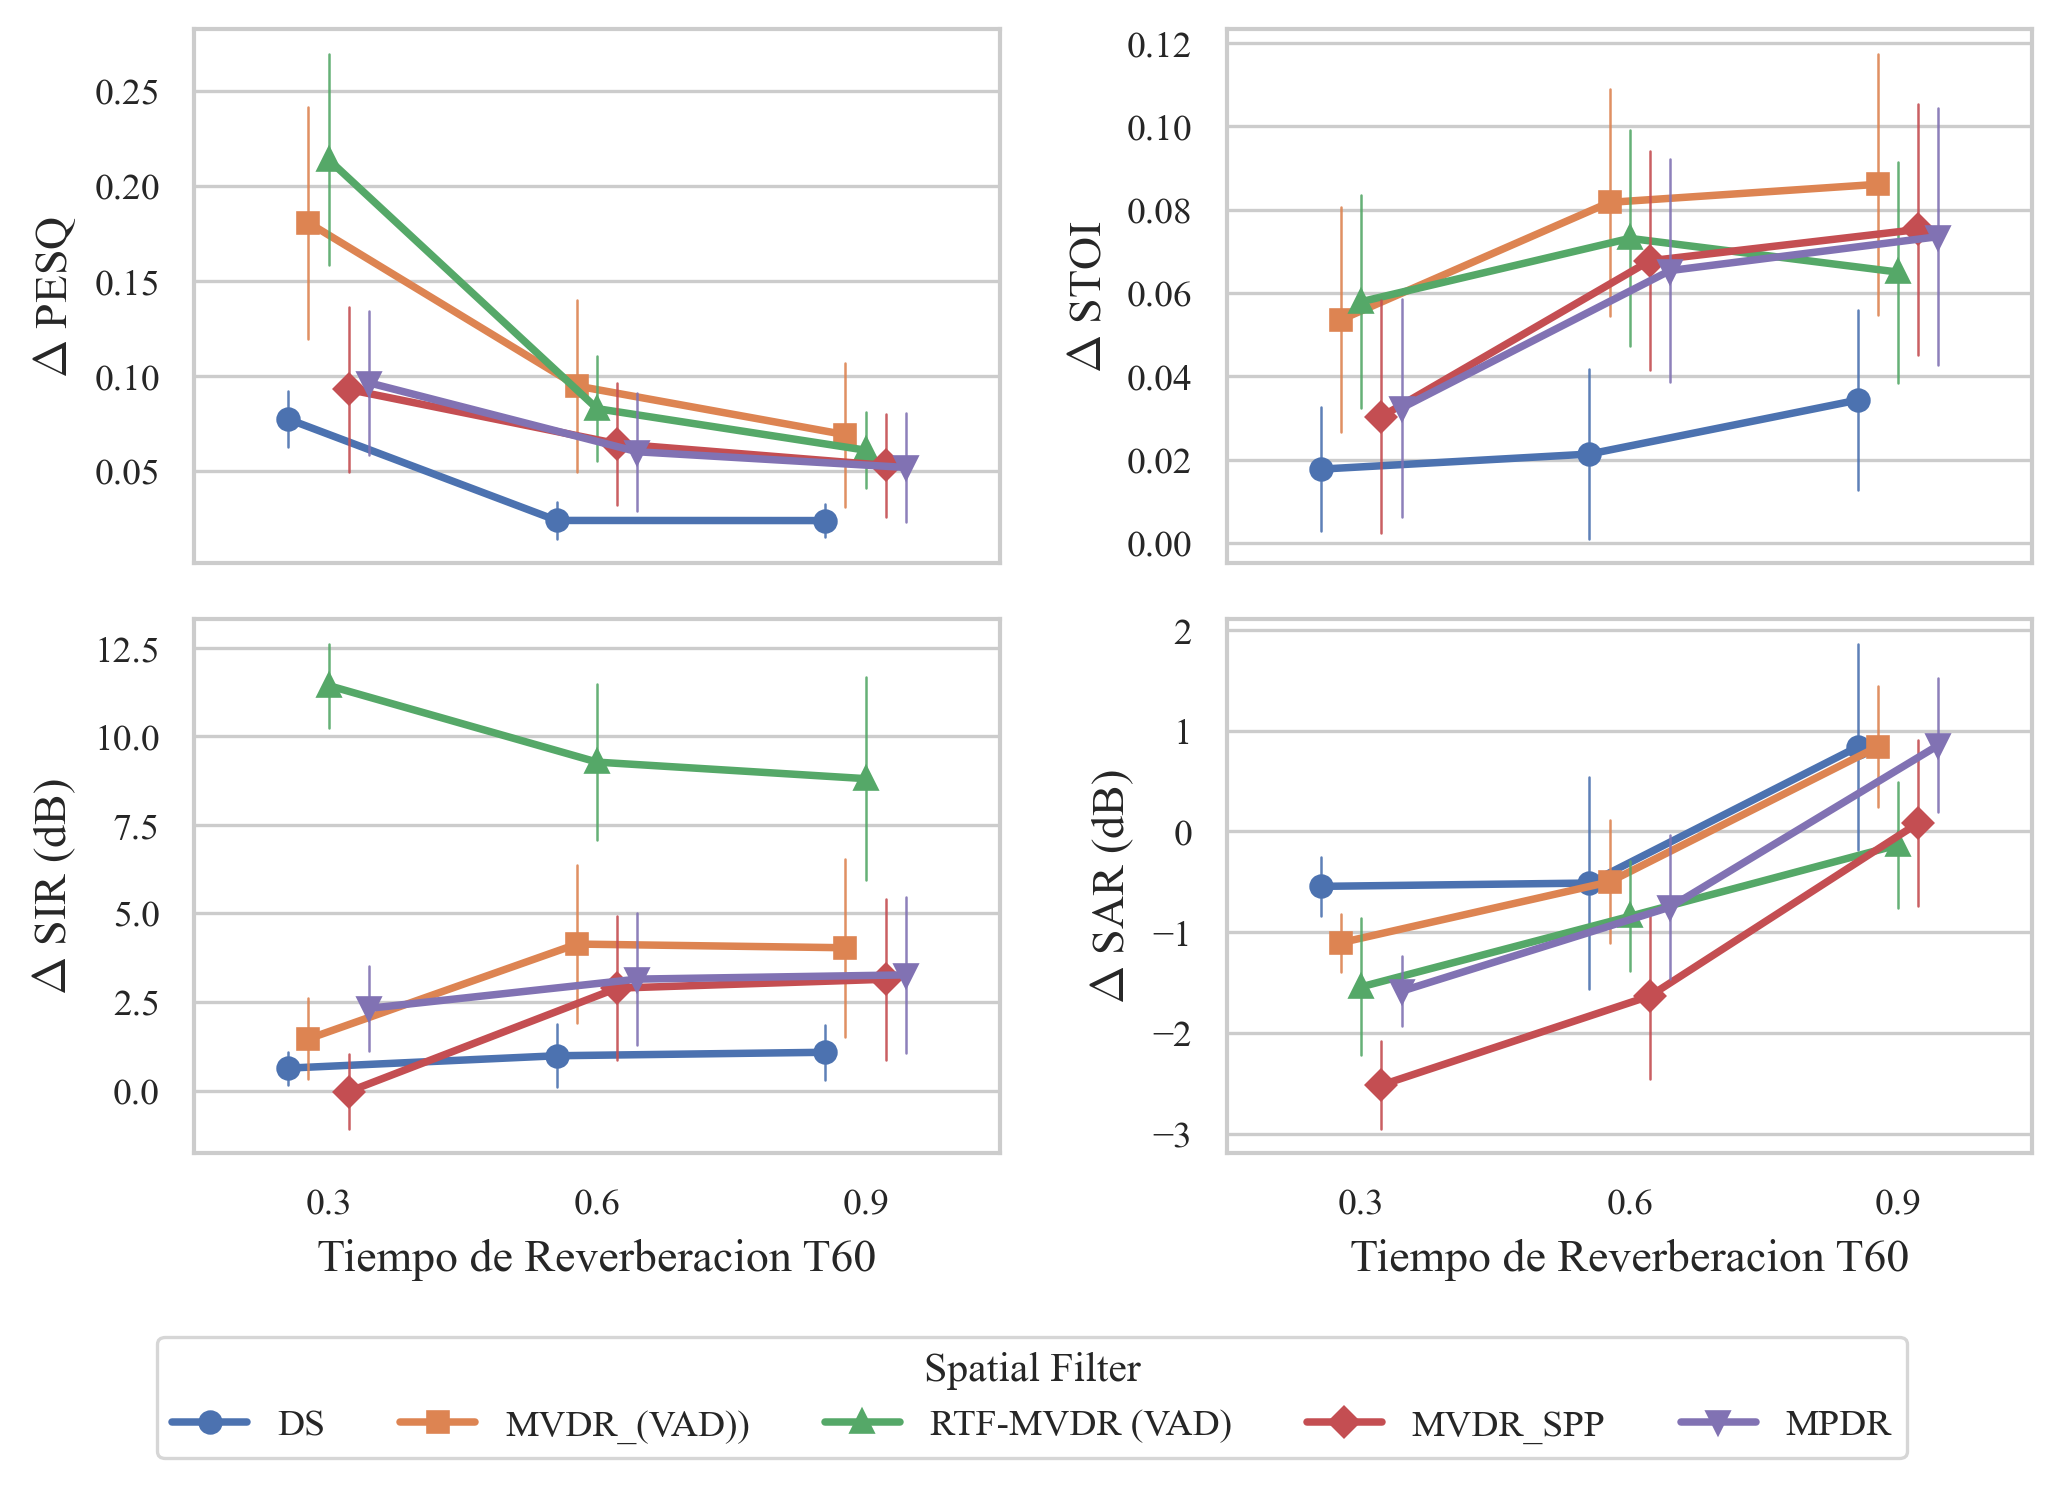

In [125]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == True].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='rt60',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberacion T60') # Updated label
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Spatial Filter',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "t60_con_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

In [126]:
# ==============================================================================
# BLOCK 4: GENERATE WPE COMPARISON PLOT (AVERAGED ACROSS ALL PROCESSORS)
# ==============================================================================

def plot_wpe_comparison_vs_rt60(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR).
    Averages the performance of all spatial filters and compares the results 
    with and without WPE pre-processing over different reverberation times.
    """
    # We need the full dataset (no WPE filter applied here)
    df_plot = df.copy()
    
    # Create a new column with readable labels for the legend
    df_plot['Condición WPE'] = df_plot['use_wpe'].map({True: 'Con WPE', False: 'Sin WPE'})
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, pdffigsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Only two markers needed now
    markers = ['o', 's']
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot will automatically calculate the mean of all processors
        sns.pointplot(
            data=df_plot, 
            x='rt60',                 # Evaluated against reverberation time
            y=metric_col, 
            hue='Condición WPE',      # Hue changed to WPE status
            dodge=0.1,                # Reduced dodge since there are only 2 lines
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberación ($RT_{60}$)')
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Pre-procesamiento',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=2,                      # Only two columns for the legend
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "deltas_vs_rt_wpe_sin_con.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function (pass the complete dataframe)
plot_wpe_comparison_vs_rt60(df_metrics)

AttributeError: Figure.set() got an unexpected keyword argument 'pdffigsize'